In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("student-record.csv")

In [5]:
df.describe()

,Roll_No,Assignment_Count,Assessment_Score,Total_Marks
count,50.00000,46.000000,50.000000,49.000000
mean,25.50000,3.391304,7.599800,81.126531
std,14.57738,2.038281,5.693319,54.434436
min,1.00000,0.000000,-3.000000,59.880000
25%,13.25000,2.250000,6.425000,65.470000
50%,25.50000,4.000000,7.040000,74.210000
75%,37.75000,4.750000,7.585000,78.300000
max,50.00000,12.000000,45.000000,450.000000


In [6]:
df.shape

(50, 7)

In [7]:
df.head(5)

,Roll_No,Student_Name,Attendance,Assignment_Count,Assessment_Score,Class_Evaluation,Total_Marks
0,1,Student1,Present,NaN,7.10,Excellent,64.20
1,2,Student2,NaN,5.0,6.64,Average,78.30
2,3,Student3,Absent,NaN,7.11,Good,81.27
3,4,Student4,Present,5.0,4.61,Excellent,65.43
4,5,Student5,Present,4.0,6.74,Excellent,79.71


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Roll_No           50 non-null     int64  
 1   Student_Name      50 non-null     object 
 2   Attendance        45 non-null     object 
 3   Assignment_Count  46 non-null     float64
 4   Assessment_Score  50 non-null     float64
 5   Class_Evaluation  47 non-null     object 
 6   Total_Marks       49 non-null     float64
dtypes: float64(3), int64(1), object(3)
memory usage: 2.9+ KB


In [9]:
print(df.isnull().sum())

Roll_No             0
Student_Name        0
Attendance          5
Assignment_Count    4
Assessment_Score    0
Class_Evaluation    3
Total_Marks         1
dtype: int64


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

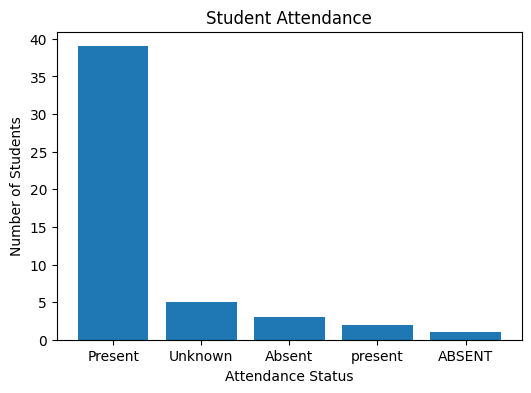

In [11]:
attendance_counts = df["Attendance"].fillna("Unknown").value_counts()

plt.figure(figsize=(6,4))
plt.bar(attendance_counts.index, attendance_counts.values)

plt.title("Student Attendance")
plt.xlabel("Attendance Status")
plt.ylabel("Number of Students")

plt.show()

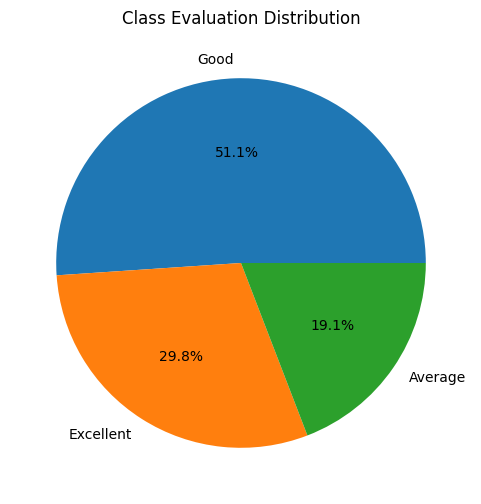

In [12]:
evaluation_counts = df["Class_Evaluation"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    evaluation_counts,
    labels=evaluation_counts.index,
    autopct="%1.1f%%"
)

plt.title("Class Evaluation Distribution")

plt.show()

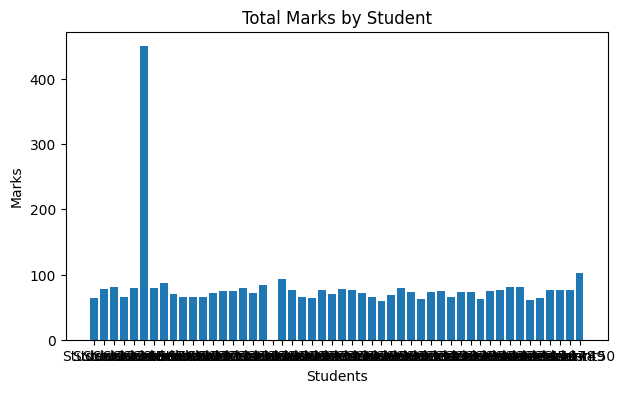

In [13]:
plt.figure(figsize=(7,4))

plt.bar(df["Student_Name"], df["Total_Marks"])

plt.title("Total Marks by Student")
plt.xlabel("Students")
plt.ylabel("Marks")

plt.show()

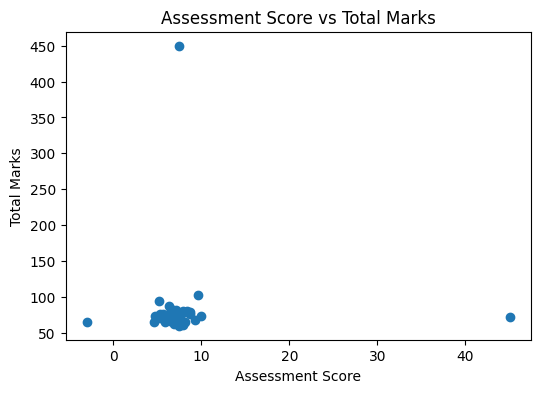

In [14]:
plt.figure(figsize=(6,4))

plt.scatter(
    df["Assessment_Score"],
    df["Total_Marks"]
)

plt.xlabel("Assessment Score")
plt.ylabel("Total Marks")
plt.title("Assessment Score vs Total Marks")

plt.show()

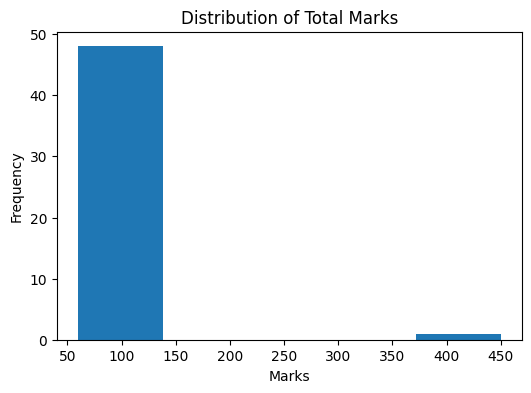

In [15]:
plt.figure(figsize=(6,4))

plt.hist(df["Total_Marks"], bins=5)

plt.title("Distribution of Total Marks")
plt.xlabel("Marks")
plt.ylabel("Frequency")

plt.show()

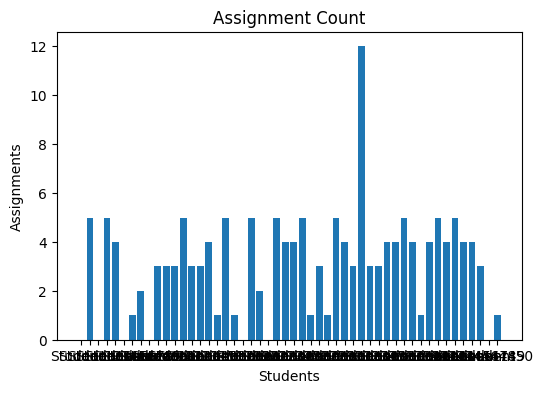

In [16]:
assignment = df["Assignment_Count"].fillna(0)

plt.figure(figsize=(6,4))

plt.bar(df["Student_Name"], assignment)

plt.title("Assignment Count")
plt.xlabel("Students")
plt.ylabel("Assignments")

plt.show()

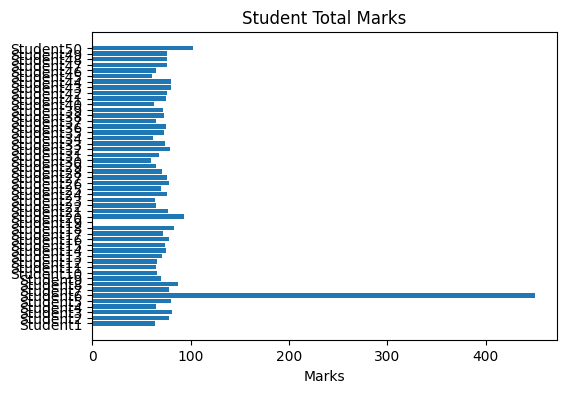

In [17]:
plt.figure(figsize=(6,4))

plt.barh(df["Student_Name"], df["Total_Marks"])

plt.title("Student Total Marks")

plt.xlabel("Marks")

plt.show()

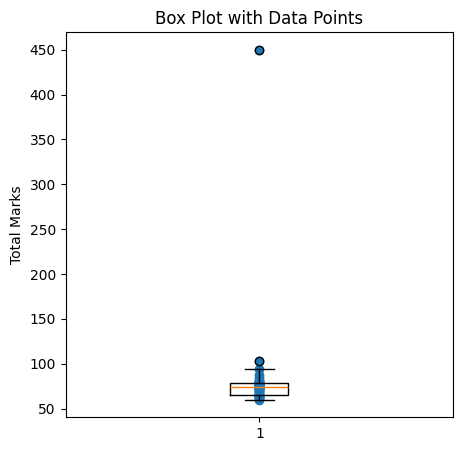

In [18]:
marks = df["Total_Marks"].dropna()

plt.figure(figsize=(5, 5))

# Draw boxplot
plt.boxplot(marks)

# Draw individual points
plt.scatter([1] * len(marks), marks)

plt.title("Box Plot with Data Points")
plt.ylabel("Total Marks")

plt.show()

In [19]:
print(df.isnull().sum())

Roll_No             0
Student_Name        0
Attendance          5
Assignment_Count    4
Assessment_Score    0
Class_Evaluation    3
Total_Marks         1
dtype: int64


In [20]:
# Strategy 1: Drop rows with any missing values
df_strategy1 = df.copy()
dropped = df.dropna()

print(f"Original rows: {len(df_strategy1)}, Rows after dropping: {len(dropped)}")

Original rows: 50, Rows after dropping: 38


In [21]:
dropped.describe()

,Roll_No,Assignment_Count,Assessment_Score,Total_Marks
count,38.000000,38.000000,38.000000,38.000000
mean,27.763158,3.210526,8.129474,73.339737
std,14.043243,1.662917,6.255509,8.108448
min,4.000000,0.000000,4.610000,59.880000
25%,16.250000,2.000000,6.425000,66.585000
50%,27.500000,4.000000,7.040000,74.220000
75%,39.750000,4.750000,7.887500,76.880000
max,50.000000,5.000000,45.000000,102.820000


In [22]:
print(dropped.isnull().sum())

Roll_No             0
Student_Name        0
Attendance          0
Assignment_Count    0
Assessment_Score    0
Class_Evaluation    0
Total_Marks         0
dtype: int64


In [24]:
df_strategy2 = df.copy()

# Find rows where 'Attendance' is null and fill manually
null_attendance_indices = df_strategy2[df_strategy2['Attendance'].isnull()].index
for idx in null_attendance_indices:
    # Example manual decision rule or looking up hardcopy records
    df_strategy2.at[idx, 'Attendance'] = 'Present' 



In [25]:
print(df_strategy2.isnull().sum())

Roll_No             0
Student_Name        0
Attendance          0
Assignment_Count    4
Assessment_Score    0
Class_Evaluation    3
Total_Marks         1
dtype: int64


In [26]:
df_strategy3 = df.copy()

# Fill categorical missing values with a constant string
df_strategy3['Attendance'] = df_strategy3['Attendance'].fillna('Unknown')

# Fill numerical missing values with a constant number
df_strategy3['Assignment_Count'] = df_strategy3['Assignment_Count'].fillna(-1)

print(df_strategy3.head())

   Roll_No Student_Name Attendance  Assignment_Count  Assessment_Score  \
0        1     Student1    Present              -1.0              7.10   
1        2     Student2    Unknown               5.0              6.64   
2        3     Student3     Absent              -1.0              7.11   
3        4     Student4    Present               5.0              4.61   
4        5     Student5    Present               4.0              6.74   

  Class_Evaluation  Total_Marks  
0        Excellent        64.20  
1          Average        78.30  
2             Good        81.27  
3        Excellent        65.43  
4        Excellent        79.71  


In [29]:
df_strategy4 = df.copy()

# 1. Fill categorical with Mode
attendance_mode = df_strategy4['Attendance'].mode()[0]
df_strategy4['Attendance'] = df_strategy4['Attendance'].fillna(attendance_mode)



print(f"Filled Attendance with Mode: {attendance_mode}")

Filled Attendance with Mode: Present


In [30]:
print(df_strategy2.isnull().sum())

Roll_No             0
Student_Name        0
Attendance          0
Assignment_Count    4
Assessment_Score    0
Class_Evaluation    3
Total_Marks         1
dtype: int64


In [32]:
df_strategy5 = df.copy()

# 1. Clean: Force to numbers (turns text/spaces into actual NaNs)
df_strategy5['Assessment_Score'] = pd.to_numeric(df_strategy5['Assessment_Score'], errors='coerce')

# 2. Fill: Group by evaluation and fill NaNs with that group's mean score
group_means = df_strategy5.groupby('Class_Evaluation')['Assessment_Score'].transform('mean')
df_strategy5['Assessment_Score'] = df_strategy5['Assessment_Score'].fillna(group_means)

print(df_strategy5[['Class_Evaluation', 'Assessment_Score']].head())

  Class_Evaluation  Assessment_Score
0        Excellent              7.10
1          Average              6.64
2             Good              7.11
3        Excellent              4.61
4        Excellent              6.74


In [ ]:
from sklearn.impute import KNNImputer

df_strategy6 = df.copy()
num_cols = ['Assignment_Count', 'Assessment_Score', 'Total_Marks']


df_strategy6[num_cols] = df_strategy6[num_cols].apply(pd.to_numeric, errors='coerce')
df_strategy6[num_cols] = KNNImputer(n_neighbors=3).fit_transform(df_strategy6[num_cols]).round()

print(df_strategy6[num_cols].head())

   Assignment_Count  Assessment_Score  Total_Marks
0               2.0               7.0         64.0
1               5.0               7.0         78.0
2               3.0               7.0         81.0
3               5.0               5.0         65.0
4               4.0               7.0         80.0
